In [ ]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = "../data/defects4j"

N_RANK = 1
REPETITION = 1

RESULT_30DAYS_PATH = f"../combined_fl_results/reportfl/gpt-3.5-turbo-0125_R{REPETITION}_full_light.json"
RESULT_60DAYS_PATH = f"../combined_fl_results/reportfl_60days/gpt-3.5-turbo-0125_R{REPETITION}_full_light.json"
RESULT_90DAYS_PATH = f"../combined_fl_results/reportfl_90days/gpt-3.5-turbo-0125_R{REPETITION}_full_light.json"

CURRENT_FILE_NAME = "current_report.json"
RECENT_30DAYS_FILE_NAME = "relevant_reports_timewindow_30.json"
RECENT_60DAYS_FILE_NAME = "relevant_reports_timewindow_60.json"
RECENT_90DAYS_FILE_NAME = "relevant_reports_timewindow_90.json"

R = "Relevent"
P = "Partially Relevant"
I = "Irrelevant"

rpi_data = {
    'Cli_1': {'rpi_list': [I, P, I], 'sims': [0.07, 0.15, 0.03]}, 
    'Cli_28': {'rpi_list': [P, I, I], 'sims': [0.28, 0.01, 0.00]},
    'Cli_30': {'rpi_list': [R, P, I], 'sims': [0.76, 0.68, 0.07]}, 
    'Codec_10': {'rpi_list': [I, I, I], 'sims': [0.03, 0.02, 0.01]}, 
    'Compress_11': {'rpi_list': [I, I, I], 'sims': [0.10, 0.34, 0.14]}, 
    'Compress_15': {'rpi_list': [I, I, I], 'sims': [0.03, 0.02, 0.01]}, 
    'Compress_2': {'rpi_list': [P, R, I], 'sims': [0.27, 0.82, 0.03]}, 
    'Compress_30': {'rpi_list': [I, I, I], 'sims': [0.03, 0.08, 0.05]}, 
    'Compress_4': {'rpi_list': [P, I, I], 'sims': [0.28, 0.10, 0.06]}, 
    'Compress_46': {'rpi_list': [I, P, P], 'sims': [0.05, 0.14, 0.29]}, 
    'Compress_8': {'rpi_list': [I, I, I], 'sims': [0.28, 0.10, 0.07]}, 
    'JxPath_5': {'rpi_list': [I, I, I], 'sims': [0.04, 0.08, 0.02]}, 
    'Lang_11': {'rpi_list': [P, I ,I], 'sims': [0.81, 0.04, 0.03]}, 
    'Lang_16': {'rpi_list': [I, I, I], 'sims': [0.06, 0.21, 0.05]}, 
    'Lang_24': {'rpi_list': [I, I, I], 'sims': [0.07, 0.02, 0.06]}, 
    'Lang_34': {'rpi_list': [I, I, I], 'sims': [0.31, 0.27, 0.02]}, 
    'Lang_37': {'rpi_list': [I, I ,I], 'sims': [0.24, 0.02, 0.06]}, 
    'Lang_42': {'rpi_list': [I, I, I], 'sims': [0.04, 0.02, 0.03]}, 
    'Lang_49': {'rpi_list': [I, I, I], 'sims': [0.01, 0.03, 0.00]}, 
    'Lang_58': {'rpi_list': [I, I, I], 'sims': [0.03, 0.24, 0.02]}, 
    'Lang_8': {'rpi_list': [I, I, I], 'sims': [0.06, 0.02, 0.02]}, 
    'Math_11': {'rpi_list': [I, I, I], 'sims': [0.06, 0.31, 0.03]}, 
    'Math_16': {'rpi_list': [I, I, I], 'sims': [0.43, 0.13, 0.07]}, 
    'Math_20': {'rpi_list': [I, I, I], 'sims': [0.31, 0.09, 0.07]},
    'Math_43': {'rpi_list': [I, I, I], 'sims': [0.31, 0.01, 0.05]}, 
    'Math_58': {'rpi_list': [I, P, I], 'sims': [0.10, 0.27, 0.34]}, 
    'Math_76': {'rpi_list': [I, I, I], 'sims': [0.41, 0.30, 0.15]}, 
    'Math_83': {'rpi_list': [R, I, I], 'sims': [0.91, 0.66, 0.04]},
    'Math_84': {'rpi_list': [I, I, I], 'sims': [0.03, 0.27, 0.01]}, 
    'Math_86': {'rpi_list': [I, I, I], 'sims': [0.03, 0.15, 0.18]}
}

def calc_acc_at_n(data, bug_name, n_rank=1):
    """
    Calculate Acc@N (Accuracy at N)
    Returns success bug count / total bug count
    """
    buggy_methods = data.get("buggy_methods", {})
    target_bug_data = buggy_methods.get(bug_name)
    if not target_bug_data:
        return 0
    
    ranks = [
        info.get("autofl_rank")
        for info in target_bug_data.values()
        if isinstance(info, dict) and info.get("autofl_rank") is not None
    ]
    
    return min(ranks)

def calculate_corr(data, timewindow):
    correlation, p_value = stats.spearmanr(data[f'sims_{timewindow}'], data[f'rank_{timewindow}'])
    print(f"{timewindow}days corr: {correlation:.4f}, p-value: {p_value:.4f}")

    plt.figure(figsize=(10, 6))
    sns.regplot(data=data, x=f'sims_{timewindow}', y=f'rank_{timewindow}')
    plt.title(f"Correlation between Similarity and Autofl Rank (K={N_RANK}, M={REPETITION}, {timewindow}days)")
    plt.show()

In [30]:
# Load JSON data
with open(RESULT_30DAYS_PATH, "r", encoding="utf-8") as f:
    result_30days = json.load(f)
with open(RESULT_60DAYS_PATH, "r", encoding="utf-8") as f:
    result_60days = json.load(f)
with open(RESULT_30DAYS_PATH, "r", encoding="utf-8") as f:
    result_90days = json.load(f)

results_list = []

for bug_name in sorted(os.listdir(DATA_DIR)):
    if "Codec" not in bug_name:
        continue
    current_file_path = os.path.join(DATA_DIR, bug_name, CURRENT_FILE_NAME)
    recent_30days_file_path = os.path.join(DATA_DIR, bug_name, RECENT_30DAYS_FILE_NAME)
    recent_60days_file_path = os.path.join(DATA_DIR, bug_name, RECENT_60DAYS_FILE_NAME)
    recent_90days_file_path = os.path.join(DATA_DIR, bug_name, RECENT_90DAYS_FILE_NAME)
    
    rank_30 = rank_60 = rank_90 = -1
    sims_30 = sims_60 = sims_90 = -1
    
    if not os.path.isfile(os.path.join(DATA_DIR, bug_name, CURRENT_FILE_NAME)):
        continue

    if os.path.isfile(recent_30days_file_path):
        rank_30 = calc_acc_at_n(result_30days, bug_name, N_RANK)
        with open(recent_30days_file_path, "r", encoding="utf-8") as f:
            relevant_reports = json.load(f)
            sims_30 = max(report["similarity"] for report in relevant_reports)
    
    if os.path.isfile(recent_60days_file_path):
        rank_60 = calc_acc_at_n(result_60days, bug_name, N_RANK)
        with open(recent_60days_file_path, "r", encoding="utf-8") as f:
            relevant_reports = json.load(f)
            sims_60 = max(report["similarity"] for report in relevant_reports)

    if os.path.isfile(recent_90days_file_path):
        rank_90 = calc_acc_at_n(result_90days, bug_name, N_RANK)
        with open(recent_90days_file_path, "r", encoding="utf-8") as f:
            relevant_reports = json.load(f)
            sims_90 = max(report["similarity"] for report in relevant_reports)

    results_list.append({
        'bug_name': bug_name,
        'rank_30': rank_30, 'sims_30': sims_30,
        'rank_60': rank_60, 'sims_60': sims_60,
        'rank_90': rank_90, 'sims_90': sims_90,
        'llm_sims_90': max(rpi_data[bug_name]['sims']) if bug_name in rpi_data else -1
    })

df = pd.DataFrame(results_list)

30days corr: 0.2294, p-value: 0.4975


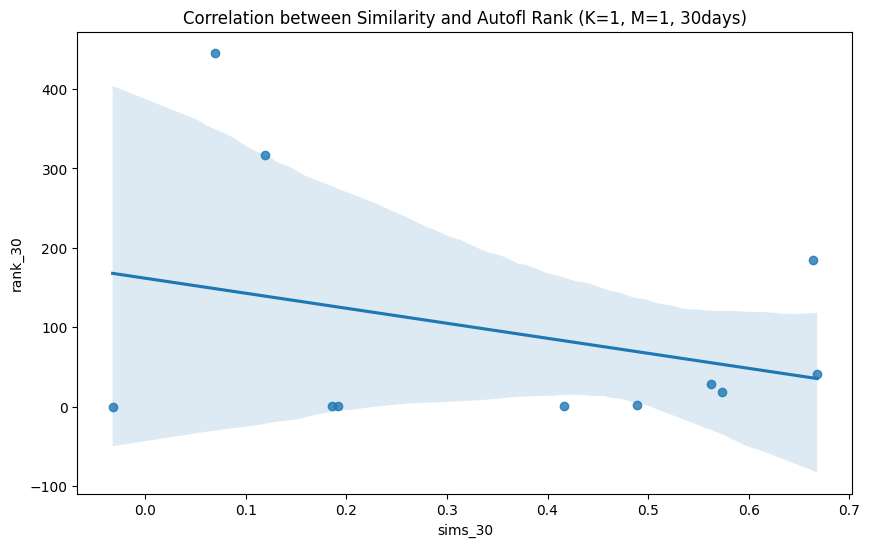

60days corr: -0.5673, p-value: 0.0343


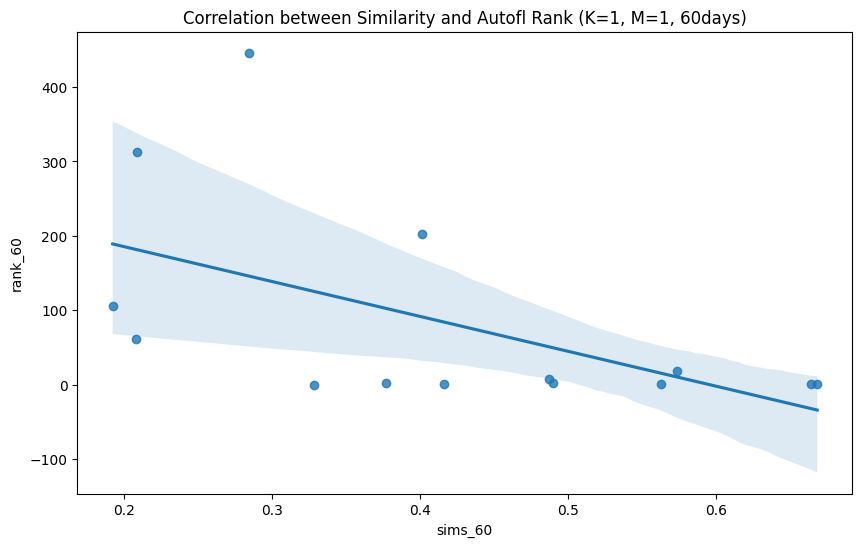

90days corr: 0.0267, p-value: 0.9218


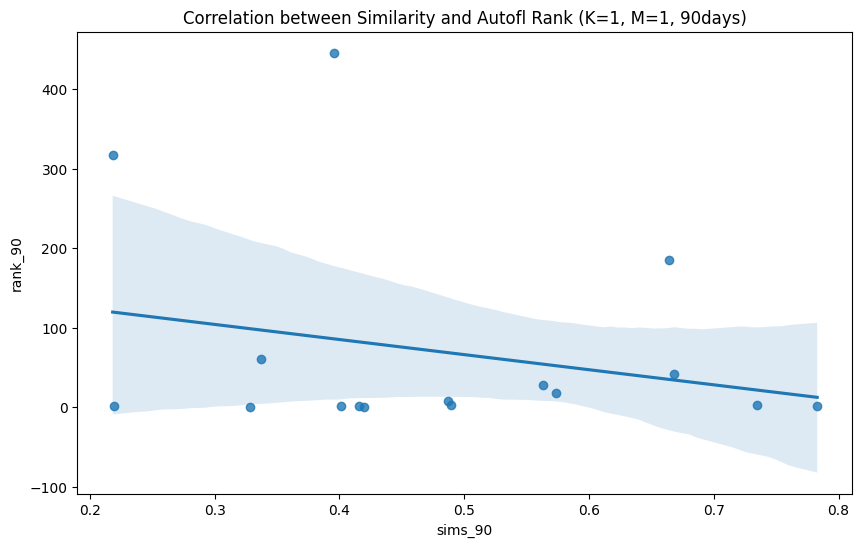

In [31]:
# Calculate correlation between lexcial similality and autofl rank for entire bugs

# 30 Days
data = df[df['sims_30'] != -1]
calculate_corr(data=data, timewindow=30)

# 60 Days
data = df[df['sims_60'] != -1]
calculate_corr(data=data, timewindow=60)

# 90 Days
data = df[df['sims_90'] != -1]
calculate_corr(data=data, timewindow=90)

30days corr: nan, p-value: nan


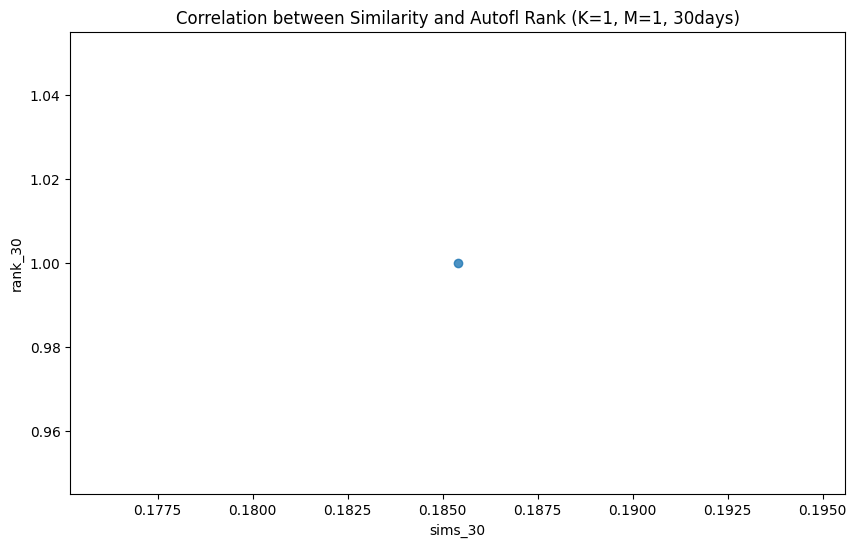

60days corr: nan, p-value: nan


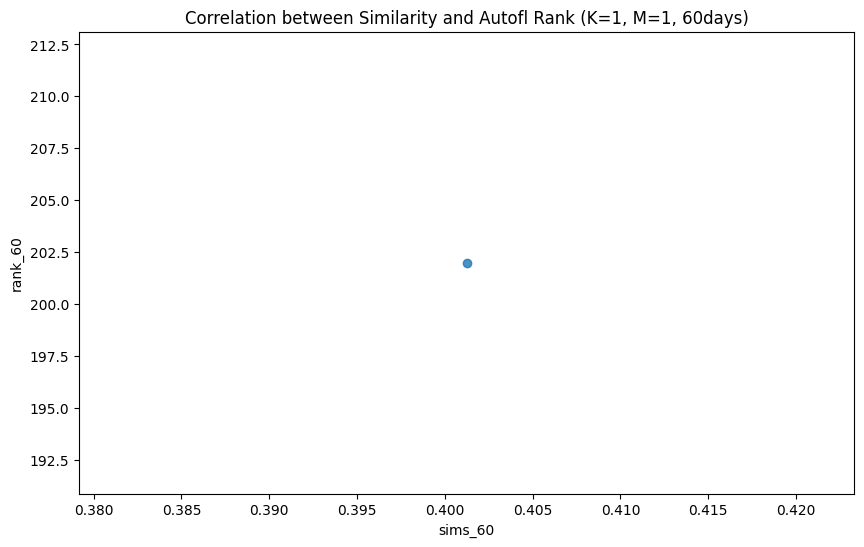

90days corr: nan, p-value: nan


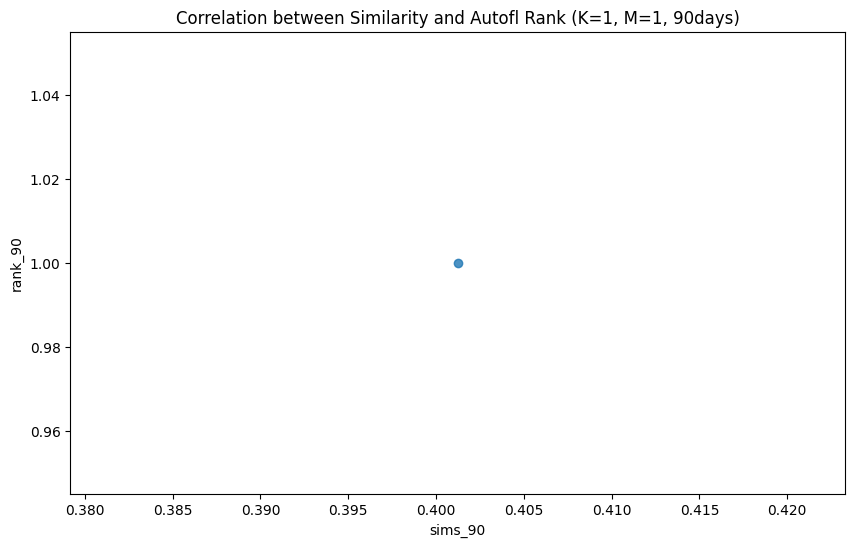

In [32]:
# Calculate correlation between lexcial similality and autofl rank for filtered bugs

# 30 Days
data = df[(df['sims_30'] != -1) & (df['bug_name'].isin(list(rpi_data.keys())))]
calculate_corr(data=data, timewindow=30)

# 60 Days
data = df[(df['sims_60'] != -1) & (df['bug_name'].isin(list(rpi_data.keys())))]
calculate_corr(data=data, timewindow=60)

# 90 Days
data = df[(df['sims_90'] != -1) & (df['bug_name'].isin(list(rpi_data.keys())))]
calculate_corr(data=data, timewindow=90)

90days corr: nan, p-value: nan


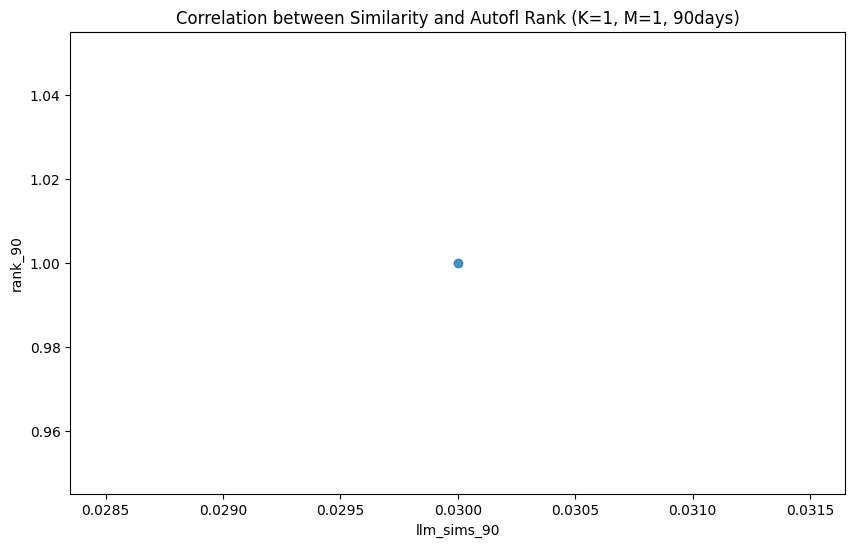

In [33]:
# Calculate correlation between semantic(llm) similality and autofl rank

data = df[(df['llm_sims_90'] != -1) & (df['bug_name'].isin(list(rpi_data.keys())))]
correlation, p_value = stats.spearmanr(data['llm_sims_90'], data['rank_90'])

print(f"90days corr: {correlation:.4f}, p-value: {p_value:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=data, x='llm_sims_90', y='rank_90')
plt.title(f"Correlation between Similarity and Autofl Rank (K={N_RANK}, M={REPETITION}, 90days)")
plt.show()
